In [1]:
# --- IMPORTAÇÕES ---
# Importa a biblioteca pandas e a apelida de 'pd'.
# O pandas é a principal ferramenta para manipulação e análise de dados.
import pandas as pd
# Importa o submódulo 'pyplot' da biblioteca 'matplotlib' e o apelida de 'plt'.
# O matplotlib é usado para criar gráficos e visualizações.
import matplotlib.pyplot as plt # Para o gráfico final
# --- TAREFA 1: CRIAR NOSSOS DADOS NOVOS ---
# Aqui, em vez de ler um Excel, estamos criando os dados do zero.
# 1. Dados da "Planilha A" (Nossos Pedidos)
# Criamos um dicionário Python. As chaves ('id_pedido', 'id_produto'...)
# serão os nomes das colunas.
dados_pedidos = {
'id_pedido': [101, 102, 103, 104, 105, 106],
'id_produto': [3, 1, 2, 1, 3, 2], # Note que os IDs de produto se repetem
'valor_total': [150.00, 4500.00, 80.00, 4800.00, 160.00, 90.00]
}
# Usamos o construtor pd.DataFrame() para converter nosso dicionário
# em um DataFrame (uma tabela) do pandas.
df_pedidos = pd.DataFrame(dados_pedidos)
# 2. Dados da "Planilha B" (Nosso Cadastro de Produtos)
# Criamos um segundo dicionário para simular outra planilha.
# Esta tabela servirá como um "cadastro" ou "tabela de consulta".
dados_produtos = {
'id_produto': [1, 2, 3], # Chave única
'nome_produto': ['Notebook G10', 'Mouse Óptico', 'Teclado Mecânico'],
'categoria': ['Eletrônico', 'Periférico', 'Periférico']
}
# Convertemos o segundo dicionário em outro DataFrame.
df_produtos = pd.DataFrame(dados_produtos)

# Apenas imprimimos os DataFrames que acabamos de criar para ver como eles são.
print("--- 1. Nossos DataFrames Separados ---")
print("Planilha de Pedidos:")
print(df_pedidos)
print("\nPlanilha de Cadastro de Produtos:")
print(df_produtos)
print("\n" + "="*40 + "\n") # Imprime uma linha de "=" para separar visualmente

--- 1. Nossos DataFrames Separados ---
Planilha de Pedidos:
   id_pedido  id_produto  valor_total
0        101           3        150.0
1        102           1       4500.0
2        103           2         80.0
3        104           1       4800.0
4        105           3        160.0
5        106           2         90.0

Planilha de Cadastro de Produtos:
   id_produto      nome_produto   categoria
0           1      Notebook G10  Eletrônico
1           2      Mouse Óptico  Periférico
2           3  Teclado Mecânico  Periférico




In [2]:
# --- TAREFA 2: USANDO FUNÇÕES PYTHON (.apply) ---
# (A "particularidade" do Python para criar lógica customizada)
# Problema: Queremos classificar cada pedido como 'Prioritário' (se > R$ 1000)
# ou 'Normal' (se <= R$ 1000).
# 1. Definimos a função Python "pura"
# Usamos 'def' para criar uma função chamada 'classificar_prioridade'.
# Ela espera receber um argumento, que chamamos de 'valor'.
def classificar_prioridade(valor):
#"""Se o valor for maior que 1000, retorna 'Prioritário', senão 'Normal'."""
# Lógica 'if/else' padrão do Python
    if valor > 1000:
        return 'Prioritário'
    else:
        return 'Normal'
# 2. Usamos o .apply() para aplicar essa função
# Criamos uma NOVA coluna em 'df_pedidos' chamada 'Prioridade'.
# O conteúdo dessa coluna será o resultado de:
# - Pegar a coluna 'valor_total' (df_pedidos['valor_total'])
# - Usar o método .apply() nela
# - Passar nossa função (classificar_prioridade) como argumento.
# O pandas vai "chamar" essa função para cada linha da coluna 'valor_total'.
df_pedidos['Prioridade'] = df_pedidos['valor_total'].apply(classificar_prioridade)
# Imprime o DataFrame de pedidos atualizado para vermos a nova coluna
print("--- 2. Pedidos com a Prioridade (após .apply()) ---")
print(df_pedidos)
print("\n" + "="*40 + "\n")

--- 2. Pedidos com a Prioridade (após .apply()) ---
   id_pedido  id_produto  valor_total   Prioridade
0        101           3        150.0       Normal
1        102           1       4500.0  Prioritário
2        103           2         80.0       Normal
3        104           1       4800.0  Prioritário
4        105           3        160.0       Normal
5        106           2         90.0       Normal




In [3]:
# --- TAREFA 3: JUNTANDO PLANILHAS (.merge) ---
# (O "PROCV" do Pandas para cruzar dados)
# Problema: A tabela 'df_pedidos' só tem o ID do produto.
# Queremos trazer o 'nome_produto' e a 'categoria' da 'df_produtos'.
# 1. Usamos a função pd.merge() para combinar os DataFrames
df_completo = pd.merge(
    
left=df_pedidos, # Planilha da Esquerda (nossa base principal)
right=df_produtos, # Planilha da Direita (de onde queremos buscar dados)
on='id_produto', # A "coluna-chave" que existe nas duas tabelas
# e que o pandas usará para fazer a ligação.
how='left' # 'how=left' (junção à esquerda) significa:
# Mantenha TODAS as linhas de 'df_pedidos' (left)
# e traga as colunas de 'df_produtos' (right)
# onde o 'id_produto' for igual.
)
# Imprime o novo DataFrame 'df_completo', que agora tem todas as colunas
print("--- 3. Relatório Final Juntado (após .merge()) ---")
print(df_completo)
print("\n" + "="*40 + "\n")

--- 3. Relatório Final Juntado (após .merge()) ---
   id_pedido  id_produto  valor_total   Prioridade      nome_produto  \
0        101           3        150.0       Normal  Teclado Mecânico   
1        102           1       4500.0  Prioritário      Notebook G10   
2        103           2         80.0       Normal      Mouse Óptico   
3        104           1       4800.0  Prioritário      Notebook G10   
4        105           3        160.0       Normal  Teclado Mecânico   
5        106           2         90.0       Normal      Mouse Óptico   

    categoria  
0  Periférico  
1  Eletrônico  
2  Periférico  
3  Eletrônico  
4  Periférico  
5  Periférico  




--- 4. Análise Final: Receita Total por Categoria ---
categoria
Eletrônico    9300.0
Periférico     480.0
Name: valor_total, dtype: float64


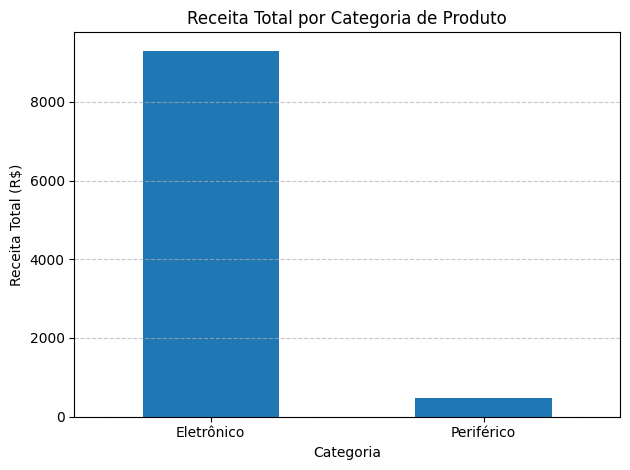

In [4]:
# --- TAREFA 4: ANÁLISE FINAL (O "Grand Finale") ---
# Agora que tudo está junto, podemos fazer análises ricas.
# Pergunta: Qual categoria de produto gerou mais receita (valor_total)?
# 1. Agrupamos
# Usamos o .groupby() para agrupar todas as linhas pela coluna 'categoria'
# (que veio do merge).
# Em seguida, selecionamos a coluna 'valor_total' desses grupos.
# E por fim, usamos .sum() para somar o valor de cada grupo.
receita_por_categoria = df_completo.groupby('categoria')['valor_total'].sum()
# Imprime o resultado da agregação
print("--- 4. Análise Final: Receita Total por Categoria ---")
print(receita_por_categoria)
# 2. Geramos o gráfico
# Chamamos o método .plot() diretamente no resultado do groupby.
receita_por_categoria.plot(
kind='bar', # Define o tipo de gráfico como 'barras'
title='Receita Total por Categoria de Produto', # Adiciona um título
rot=0 # Rotação dos labels do eixo X (0 = horizontal)
)
# Usamos o 'plt' (matplotlib) para refinar o gráfico
plt.ylabel("Receita Total (R$)") # Nomeia o eixo Y
plt.xlabel("Categoria") # Nomeia o eixo X
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade no eixo Y
plt.tight_layout() # Comando para ajustar o gráfico e evitar que cortes
plt.show() # Comando final para "mostrar" a janela do gráfico